In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('CreditScoring.csv')

In [5]:
df.columns = df.columns.str.lower()

In [6]:
# decoding categorical variables from R 
df.status = df.status.map({1: 'ok', 2: 'default', 0: 'unknown'})

df.home = df.home.map({
    1: 'rent', 
    2: 'owner',
    3: 'priv',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unknown'})

df.marital = df.marital.map({
    1: 'single', 
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unknown'
})

df.records = df.records.map({
    1: 'no_rec', 
    2: 'yes_rec'})

df.job = df.job.map({
    1: 'fixed', 
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unknown'})

In [25]:
df[['marital', 'home', 'status', 'records', 'job']] = df[['marital', 'home', 'status', 'records', 'job']].astype('str') #convert string fields into string data types

In [9]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no_rec,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no_rec,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes_rec,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no_rec,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no_rec,fixed,46,107,0,0,310,910


In [10]:
df.dtypes

status         str
seniority    int64
home           str
time         int64
age          int64
marital        str
records        str
job            str
expenses     int64
income       int64
assets       int64
debt         int64
amount       int64
price        int64
dtype: object

In [12]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [15]:
numericals = list(df.dtypes[df.dtypes == 'int'].index) #list of numerical columns

In [17]:
for col in numericals:
    df[col] = df[col].replace(df[col].max(), np.nan)

In [24]:
df[numericals].isnull().sum()

seniority     1
time          1
age           2
expenses      1
income       34
assets       47
debt         18
amount        1
price         1
dtype: int64

In [26]:
for col in numericals:
    df[col] = df[col].fillna(df[col].median())

In [29]:
df.isnull().sum()

status       0
seniority    0
home         0
time         0
age          0
marital      0
records      0
job          0
expenses     0
income       0
assets       0
debt         0
amount       0
price        0
dtype: int64

### check for outliers in numerical columns

In [32]:

df.kurtosis(numeric_only=True)

seniority      1.741537
time          -0.434421
age           -0.631137
expenses       1.123040
income        10.155712
assets       182.062800
debt         149.892935
amount         3.710490
price         15.656248
dtype: float64

In [37]:
df[['income', 'assets', 'debt', 'amount', 'price']].describe()

,income,assets,debt,amount,price
count,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000
mean,130.487542,5378.077890,341.562963,1038.123906,1460.689338
std,86.042072,11514.557029,1243.532086,470.816388,611.120065
min,0.000000,0.000000,0.000000,100.000000,105.000000
25%,80.000000,0.000000,0.000000,700.000000,1117.500000
50%,120.000000,3000.000000,0.000000,1000.000000,1400.000000
75%,164.000000,6000.000000,0.000000,1300.000000,1691.000000
max,959.000000,300000.000000,30000.000000,4500.000000,8800.000000


In [42]:
from IPython.display import display

In [46]:

for col in ['income', 'assets', 'debt', 'amount', 'price']:
    print(col)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_outlier = df[col][(df[col] < lower_bound) | (df[col] > upper_bound )]

    display(df_outlier)
    print(len(df_outlier))

income


16      330.0
21      324.0
52      301.0
59      715.0
73      411.0
        ...  
4125    300.0
4265    700.0
4342    300.0
4364    466.0
4376    300.0
Name: income, Length: 207, dtype: float64

207
assets


16      16500.0
42      50000.0
46      15900.0
78      30000.0
93      25000.0
         ...   
4386    30000.0
4403    24000.0
4411    26000.0
4420    40000.0
4441    40000.0
Name: assets, Length: 277, dtype: float64

277
debt


...

767
amount


125     2380.0
142     3800.0
268     3000.0
293     3000.0
311     3250.0
         ...  
4358    3000.0
4364    2700.0
4369    3000.0
4386    2500.0
4414    2500.0
Name: amount, Length: 71, dtype: float64

71
price


2       2985.0
27      2557.0
100     3262.0
125     4786.0
142     8800.0
         ...  
4386    3415.0
4392    3038.0
4411    2554.0
4414    3106.0
4423    2800.0
Name: price, Length: 174, dtype: float64

174


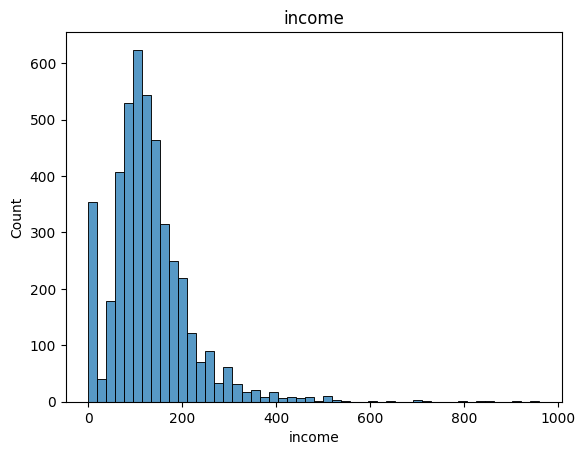

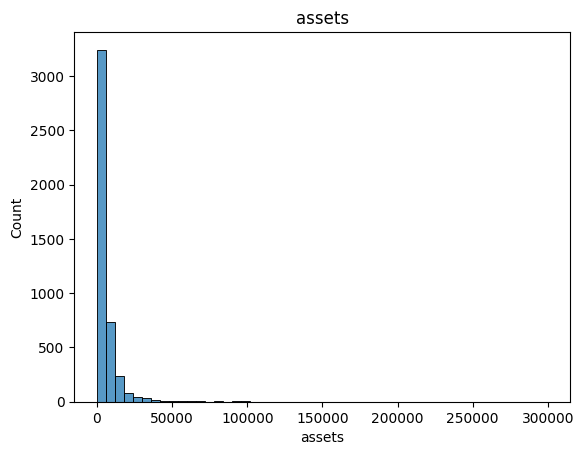

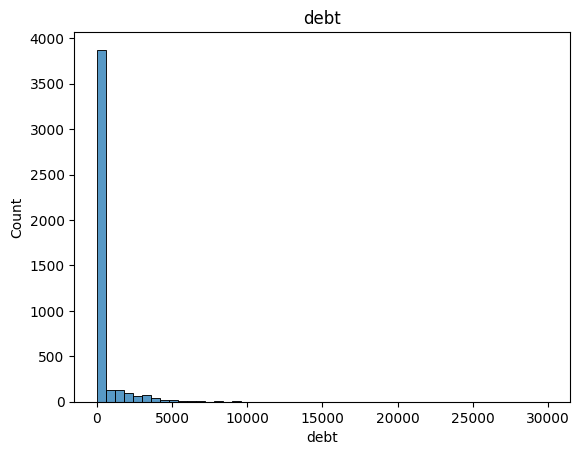

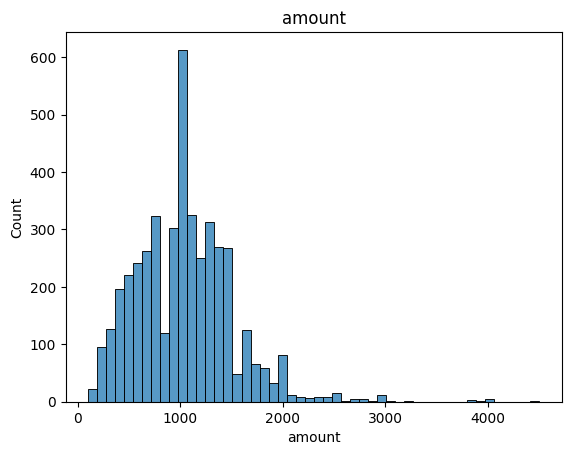

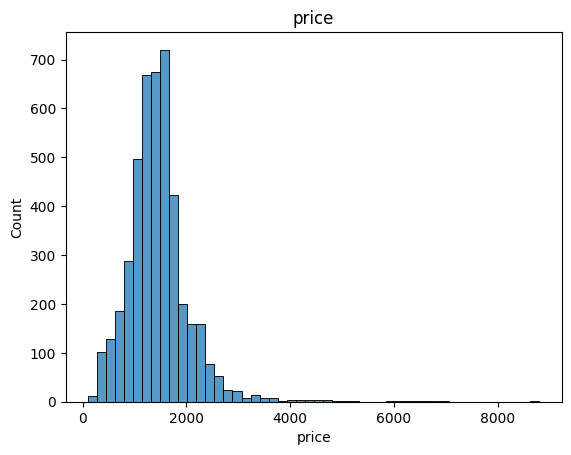

In [50]:
for col in ['income', 'assets', 'debt', 'amount', 'price']:
    plt.figure()
    sns.histplot(df[col], bins=50)
    plt.title(col)
    plt.show()
    

In [52]:
for col in ['income', 'assets', 'debt', 'amount', 'price']:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower_bound, upper_bound)

In [54]:
df[['income', 'assets', 'debt', 'amount', 'price']].describe()

,income,assets,debt,amount,price
count,4455.000000,4455.000000,4455.0,4455.000000,4455.000000
mean,126.136925,4146.978002,0.0,1029.112682,1430.618967
std,70.583272,4575.259453,0.0,437.034691,491.270341
min,0.000000,0.000000,0.0,100.000000,257.250000
25%,80.000000,0.000000,0.0,700.000000,1117.500000
50%,120.000000,3000.000000,0.0,1000.000000,1400.000000
75%,164.000000,6000.000000,0.0,1300.000000,1691.000000
max,290.000000,15000.000000,0.0,2200.000000,2551.250000


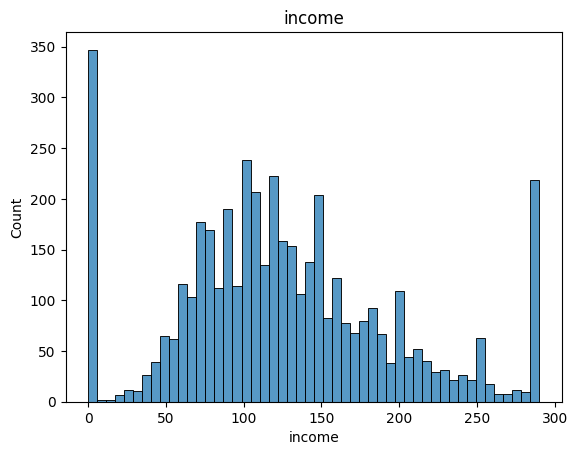

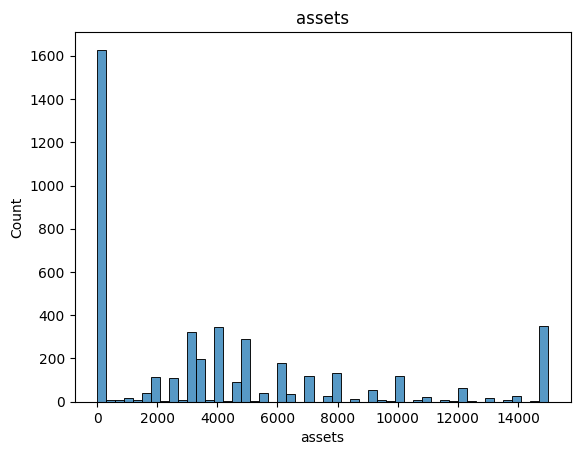

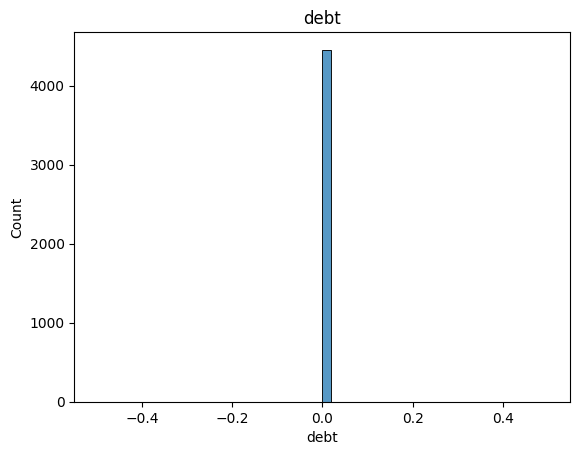

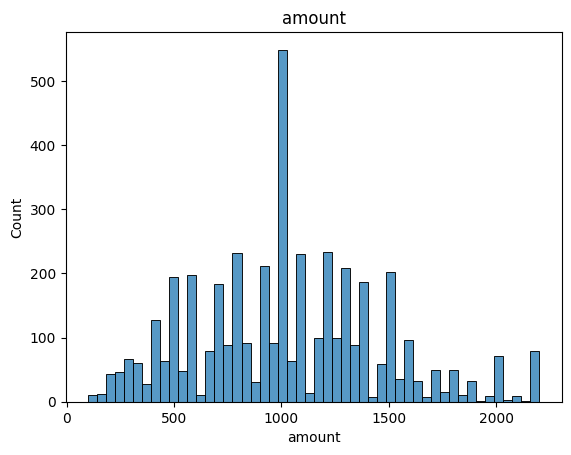

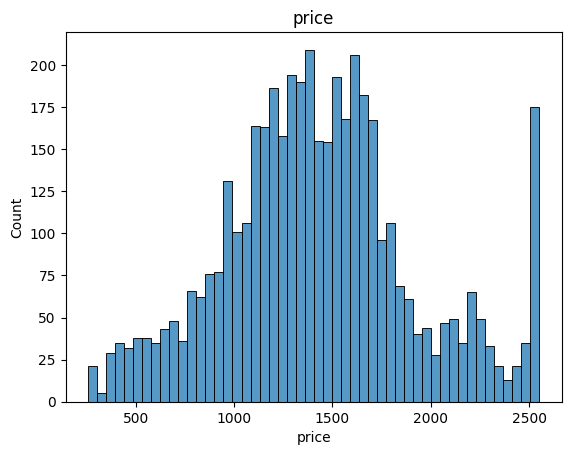

In [55]:
for col in ['income', 'assets', 'debt', 'amount', 'price']:
    plt.figure()
    sns.histplot(df[col], bins=50)
    plt.title(col)
    plt.show()
    

In [56]:
# correlation

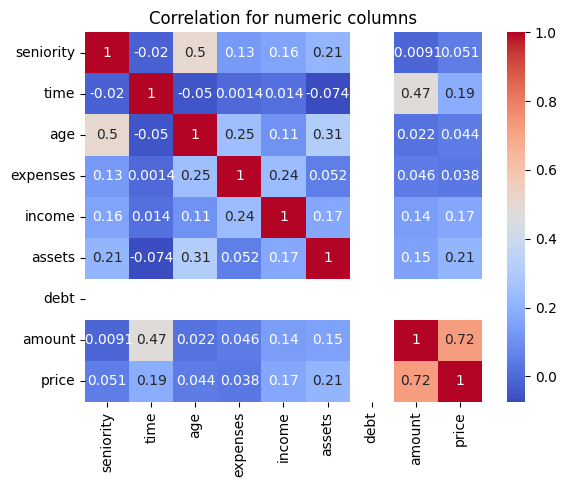

In [58]:
#from the correlatioin heatmap we can see that the price of an item is highly correlated to the amount 
# of the loan this makes sence. since the more expensive the item the client wants to buy the more money the client will need
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation for numeric columns')
plt.show()